In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2

In [2]:
df = pd.read_csv('bitcoin_sentiments_21_24.csv')
df.columns = ['date', 'text', 'sentiment_score']

In [3]:
def create_label(score):
    if score < -0.2:
        return 0
    elif score > 0.2:
        return 2
    else:
        return 1

In [4]:
df["label"] = df["sentiment_score"].apply(create_label)

In [5]:
df.head()

,date,text,sentiment_score,label
0,2021-11-05 04:42:00,Bitcoin price is consolidating near the USD 62...,0.998558,2
1,2021-11-05 08:15:00,Congress could finally approve or reject the m...,0.000000,1
2,2021-11-05 10:24:00,Bitcoin increasingly becoming a political inst...,0.000000,1
3,2021-11-05 16:58:00,There is still potential for the price of bitc...,0.999458,2
4,2021-11-05 21:00:00,'Several companies' are looking to Latin Ameri...,0.000000,1


In [6]:
# 0 = negative
# 1 = Neutral
# 2 = pozitive
print(df['label'].value_counts())

label
1    4445
2    3949
0    2901
Name: count, dtype: int64


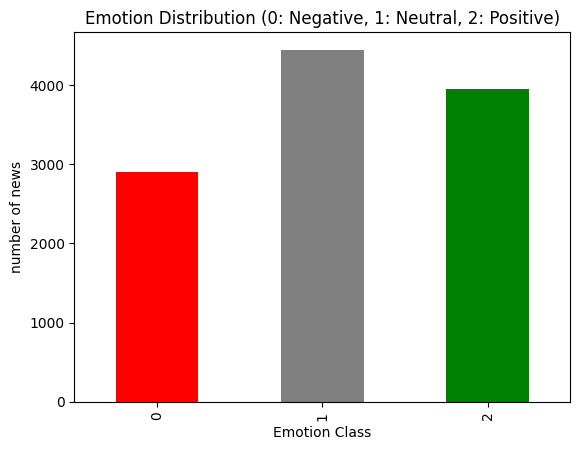

In [7]:
df['label'].value_counts().sort_index().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Emotion Distribution (0: Negative, 1: Neutral, 2: Positive)')
plt.xlabel('Emotion Class')
plt.ylabel('number of news')
plt.show()

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

In [9]:
df["clean_text"] = df["text"].apply(clean_text) 

In [10]:
X = df["clean_text"].values
y = df["label"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(f"Number of Training Data: {len(X_train_text)}")
print(f"Number of Test Data: {len(X_test_text)}")

Number of Training Data: 9036
Number of Test Data: 2259


In [12]:
vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [13]:
max_length = 100
padding_type = 'post'
trunc_type = 'post'

X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [14]:
print(f"X_train_padded: {X_train_padded.shape}")

X_train_padded: (9036, 100)


In [15]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

print(f"Class Weights: {class_weights_dict}")

Class Weights: {0: np.float64(1.2965992251399052), 1: np.float64(0.8549531649162645), 2: np.float64(0.9442006269592477)}


In [16]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
model.add(SpatialDropout1D(0.3))

model.add(Bidirectional(LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001))))
model.add(Dropout(0.5))

model.add(Dense(3, activation='softmax'))

optimizer = Adam(learning_rate=0.00005)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

C:\Users\vedat\Desktop\finsmart\venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

checkpoint = ModelCheckpoint(
    'finsmart_sentiment_v1.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

In [18]:
history = model.fit(
    X_train_padded, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_padded, y_test),
    class_weight=class_weights_dict,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/30
281/283 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3084 - loss: 1.2878
Epoch 1: val_accuracy improved from None to 0.37716, saving model to finsmart_sentiment_v1.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.3260 - loss: 1.2765 - val_accuracy: 0.3772 - val_loss: 1.2522
Epoch 2/30
281/283 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4263 - loss: 1.2358
Epoch 2: val_accuracy improved from 0.37716 to 0.48871, saving model to finsmart_sentiment_v1.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.4430 - loss: 1.2234 - val_accuracy: 0.4887 - val_loss: 1.1859
Epoch 3/30
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4810 - loss: 1.1736
Epoch 3: val_accuracy improved from 0.48871 to 0.50952, saving model to finsmart_sentiment_v1.keras
283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4863 - loss: 1.1477 - val_accuracy: 0.5095 - val_loss: 1.0871
Epoch 4/30
281/283 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5195 - loss: 1.0709
